# HW13 — токенизация, инференс BERT и fine-tuning (классификация текста)

Практическая работа 13 - Атаманчук А.В. КВБО-01-22


1. Импорты, seed и среда


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


d:\VUZ\II_DOP_KURS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


2. Данные и первичный анализ

Используем датасет emotion из HuggingFace: короткие английские тексты, метка — одна из 6 эмоций. Официальные сплиты: train / validation / test.


In [2]:
raw_datasets = load_dataset("emotion")

label_names = raw_datasets["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

print("Классы:", label_names)
print("Размеры:")
for split in raw_datasets.keys():
    print(f"  {split}: {len(raw_datasets[split])}")

print("\nПримеры:")
sample_df = pd.DataFrame(
    {
        "text": raw_datasets["train"]["text"][:5],
        "label": [id2label[i] for i in raw_datasets["train"]["label"][:5]],
    }
)
display(sample_df)


Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Размеры:
  train: 16000
  validation: 2000
  test: 2000

Примеры:


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


Постановка: по тексту предсказать эмоциональную категорию (многоклассовая классификация, ровно 6).


3. Токенизация 


In [3]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

demo_texts = raw_datasets["train"]["text"][:5]

for i, text in enumerate(demo_texts):
    print("=" * 72)
    print(f"Пример {i + 1}")
    print("Исходный текст:", text[:200], "..." if len(text) > 200 else "")
    enc = tokenizer(text, add_special_tokens=True)
    toks = tokenizer.tokenize(text)
    print("Токены:", toks[:30], ("..." if len(toks) > 30 else ""))
    print("input_ids (фрагмент):", enc["input_ids"][:25], "...")
    print("attention_mask (фрагмент):", enc["attention_mask"][:25], "...")
    print("Special tokens:", tokenizer.special_tokens_map)
    print("decode(input_ids):", tokenizer.decode(enc["input_ids"])[:200], "...")

batch_enc = tokenizer(
    demo_texts,
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)
print("\nБатч после padding=True, truncation=True, max_length=32:")
for k, v in batch_enc.items():
    print(f"  {k}: shape {tuple(v.shape)}")


Пример 1
Исходный текст: i didnt feel humiliated 
Токены: ['i', 'didn', '##t', 'feel', 'humiliated'] 
input_ids (фрагмент): [101, 1045, 2134, 2102, 2514, 26608, 102] ...
attention_mask (фрагмент): [1, 1, 1, 1, 1, 1, 1] ...
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
decode(input_ids): [CLS] i didnt feel humiliated [SEP] ...
Пример 2
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake 
Токены: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake'] 
input_ids (фрагмент): [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102] ...
attention_mask (фрагмент): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
Speci

4. Инференс готовой pretrained модели

In [4]:
pretrained_clf_name = "distilbert-base-uncased-finetuned-sst-2-english"
zero_shot_pipe = pipeline(
    "text-classification",
    model=pretrained_clf_name,
    device=0 if torch.cuda.is_available() else -1,
)

infer_texts = raw_datasets["train"]["text"][:5]
infer_rows = []
for t in infer_texts:
    out = zero_shot_pipe(t[:512])[0]
    infer_rows.append({"text": t[:120], "pipeline_label": out["label"], "score": out["score"]})

pd.DataFrame(infer_rows)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6505.51it/s]


,text,pipeline_label,score
0,i didnt feel humiliated,POSITIVE,0.891335
1,i can go from feeling so hopeless to so damned...,POSITIVE,0.966551
2,im grabbing a minute to post i feel greedy wrong,NEGATIVE,0.999305
3,i am ever feeling nostalgic about the fireplac...,POSITIVE,0.965797
4,i am feeling grouchy,NEGATIVE,0.999391


**Комментарий:** готовая модель выдаёт только метки POSITIVE / NEGATIVE с уверенностью по softmax. Для задачи emotion (6 эмоций) такая постановка не совпадает с целевым пространством меток: прямое сопоставление с sadness/joy/... невозможно без отдельной головы и обучения. Инференс полезен как демонстрация API, но для прикладной метрики нужен fine-tuning на наших данных.


5. Подготовка датасета к обучению

In [5]:
def rename_labels(example):
    return {"labels": example["label"]}


dataset_dict = raw_datasets.map(rename_labels)
dataset_dict = dataset_dict.remove_columns(["label"])


def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)


tokenized = dataset_dict.map(tokenize_fn, batched=True)
tokenized = tokenized.remove_columns(["text"])
tokenized


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [6]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5277.85it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }


ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("outputs") / "hw13_trainer"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

common_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)

try:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_kwargs,
    )


6. Fine-tuning (лучшая модель по validation f1_macro)

 Критерий отбора — максимум f1_macro на validation.

In [8]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.219824,0.225415,0.926000,0.898949
2,0.123773,0.163774,0.933000,0.906608
3,0.069838,0.152390,0.939000,0.915829


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.2373158469994863, metrics={'train_runtime': 703.8502, 'train_samples_per_second': 68.196, 'train_steps_per_second': 4.262, 'total_flos': 584777647046016.0, 'train_loss': 0.2373158469994863, 'epoch': 3.0})

7. Финальная оценка на test

In [9]:
pred_output = trainer.predict(tokenized["test"])
test_logits = pred_output.predictions
test_labels = pred_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average="macro")
print(f"test accuracy: {test_acc:.4f}")
print(f"test f1_macro: {test_f1:.4f}")


test accuracy: 0.9200
test f1_macro: 0.8733


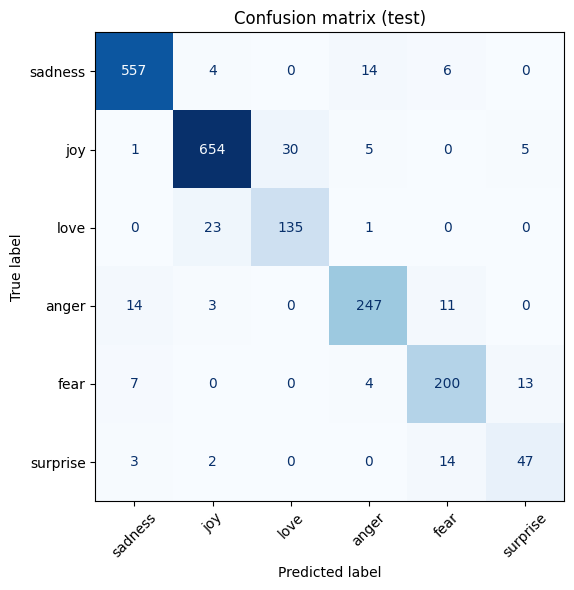

Saved: D:\VUZ\II_DOP_KURS\MIREA_III\homeworks\HW13\artifacts\confusion_matrix.png


In [10]:
cm = confusion_matrix(test_labels, test_preds, labels=np.arange(len(label_names)))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion matrix (test)")
plt.tight_layout()
cm_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print("Saved:", cm_path.resolve())


In [11]:
probs = torch.nn.functional.softmax(torch.tensor(test_logits, dtype=torch.float32), dim=-1).numpy()
confidences = probs.max(axis=1)

n_show = 10
test_texts = raw_datasets["test"]["text"]
rows = []
for i in range(len(test_texts)):
    rows.append(
        {
            "text": test_texts[i],
            "true_label": id2label[int(test_labels[i])],
            "pred_label": id2label[int(test_preds[i])],
            "confidence": float(confidences[i]),
        }
    )

pred_df_full = pd.DataFrame(rows)
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(pred_df_full), size=min(40, len(pred_df_full)), replace=False)
pred_df_sample = pred_df_full.iloc[sample_idx].reset_index(drop=True)
display(pred_df_sample.head(n_show))


,text,true_label,pred_label,confidence
0,i am feeling content and happy with myself,joy,joy,0.999187
1,i am loosing out but i feel like i have have s...,sadness,sadness,0.999074
2,i cant feel anything like they said why does e...,sadness,sadness,0.999122
3,i am most certainly an acquired taste but late...,anger,anger,0.991049
4,i am going to have to check on in just a few m...,fear,fear,0.997356
5,im still feeling pretty low and demotivated in...,sadness,sadness,0.999091
6,i can choose to tell the whole word what im fe...,sadness,sadness,0.998609
7,i feel blessed to know this family,love,love,0.538644
8,i just feel so smug that we got the exploited ...,joy,joy,0.999143
9,i can begin to see a first step and suddenly l...,sadness,sadness,0.998848


In [12]:
wrong_mask = np.array(test_preds) != np.array(test_labels)
wrong_idx = np.where(wrong_mask)[0]
print(f"Число ошибок на test: {wrong_idx.size} / {len(test_labels)}")

sample_wrong = wrong_idx[:8] if len(wrong_idx) else []
for j in sample_wrong:
    print("---")
    print("text:", test_texts[j][:300])
    print("true:", id2label[int(test_labels[j])], "| pred:", id2label[int(test_preds[j])], "| conf:", float(confidences[j]))

pred_df_sample.to_csv(ARTIFACTS_DIR / "sample_predictions.csv", index=False)
print("Saved:", (ARTIFACTS_DIR / "sample_predictions.csv").resolve())


Число ошибок на test: 160 / 2000
---
text: i don t feel particularly agitated
true: fear | pred: anger | conf: 0.8342120051383972
---
text: i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change
true: anger | pred: sadness | conf: 0.5210436582565308
---
text: i feel a bit stressed even though all the things i have going on are fun
true: anger | pred: sadness | conf: 0.8176776170730591
---
text: i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird
true: surprise | pred: fear | conf: 0.6350710391998291
---
text: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love
true: joy | pred: love | conf: 0.8169219493865967
---
text: i was feeling weird the other day and it went away about minutes after i took my metformin
true: fear | pred: surprise | conf: 0.6204414367675781
---
text: when a friend dropped

**Краткий разбор ошибок:** типичные путаницы — близкие по смыслу эмоции (joy/love, anger/sadness), короткие ироничные фразы, неоднозначный контекст. 

Для 'i feel a bit stressed even though all the things i have going on are fun' смысл крайне зависит от контекста, особенно из-за окончания 'i have going on are fun', поэтому anger/sadness.
